<a href="https://colab.research.google.com/github/beBijayeeni/sms-spam-classification-ann/blob/main/SMS_Spam_Classification_ANN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/spam.csv", encoding="latin-1")

In [ ]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df = df[['v1', 'v2']]

In [ ]:
df.columns = ['label', 'text']

In [ ]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


In [ ]:
(df['label'].value_counts(normalize=True) * 100).round(2)

,proportion
label,
ham,86.59000000
spam,13.41000000


The dataset is imbalanced, with approximately 86.59% ham messages and only 13.41% spam messages.

In [ ]:
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocess_text(text):

    # 1. Convert to lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Remove digits
    text = re.sub(r'\d+', '', text)

    # 4. Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 5. Tokenization
    tokens = word_tokenize(text)

    # 6. Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # 7. Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    # 8. Join tokens back into text
    return " ".join(tokens)

In [ ]:
df["clean_text"] = df["text"].apply(preprocess_text)

In [ ]:
df.head()

,label,text,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [ ]:
X = df["clean_text"]

In [ ]:
df["target"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

y = df["target"]

In [ ]:
print(X.head())
print(y.head())

0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry wkly comp win fa cup final tkts st ...
3                  u dun say early hor u c already say
4             nah dont think go usf life around though
Name: clean_text, dtype: object
0    0
1    0
2    1
3    0
4    0
Name: target, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training data:", X_train_text.shape)
print("Testing data:", X_test_text.shape)

Training data: (4457,)
Testing data: (1115,)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2
)

In [ ]:
X_train_tfidf = vectorizer.fit_transform(X_train_text)

In [ ]:
X_test_tfidf = vectorizer.transform(X_test_text)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [ ]:
input_dim = X_train_tfidf.shape[1]
print("Number of input features:", input_dim)

Number of input features: 7139


In [ ]:
X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

In [ ]:
model = Sequential([

    # Input + First Hidden Layer
    Dense(
        128,
        activation='relu',
        input_shape=(input_dim,)
    ),

    # Dropout to reduce overfitting
    Dropout(0.3),

    # Second Hidden Layer
    Dense(
        64,
        activation='relu'
    ),

    # Dropout
    Dropout(0.2),

    # Output Layer
    Dense(
        1,
        activation='sigmoid'
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
model_train = model.fit(
    X_train_dense,
    y_train,
    epochs=15,
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stopping]
)

Epoch 1/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8698 - loss: 0.3392 - val_accuracy: 0.8935 - val_loss: 0.1985
Epoch 2/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9790 - loss: 0.0846 - val_accuracy: 0.9776 - val_loss: 0.0935
Epoch 3/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9933 - loss: 0.0222 - val_accuracy: 0.9776 - val_loss: 0.0983
Epoch 4/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9975 - loss: 0.0092 - val_accuracy: 0.9787 - val_loss: 0.1070
Epoch 5/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9989 - loss: 0.0060 - val_accuracy: 0.9776 - val_loss: 0.1170


In [ ]:
print(model_train.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
y_pred_prob = model.predict(X_test_dense)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

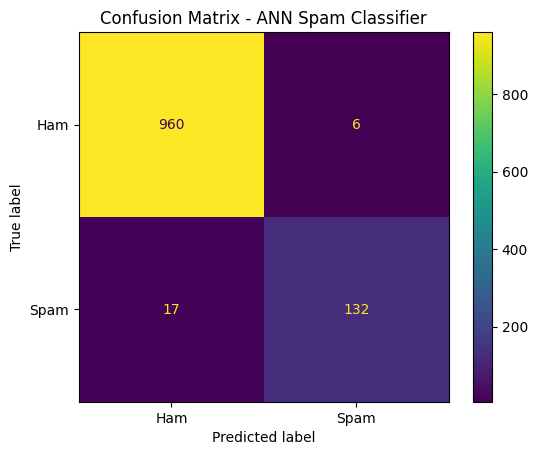

In [ ]:
cm = confusion_matrix(y_test, y_pred)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

display_cm.plot()

plt.title("Confusion Matrix - ANN Spam Classifier")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("ANN Model Performance")
print("-" * 30)
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall:    {recall * 100:.2f}%")
print(f"F1-Score:  {f1 * 100:.2f}%")

ANN Model Performance
------------------------------
Accuracy:  97.94%
Precision: 95.65%
Recall:    88.59%
F1-Score:  91.99%


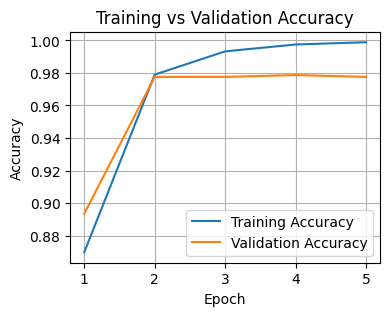

In [ ]:
import matplotlib.pyplot as plt
epochs = range(1, len(model_train.history['accuracy']) + 1)
plt.figure(figsize=(4, 3))
plt.plot(epochs, model_train.history['accuracy'], label='Training Accuracy')
plt.plot(epochs, model_train.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

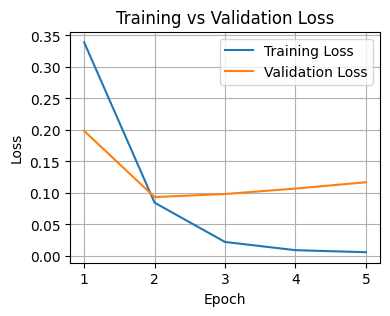

In [ ]:
epochs = range(1, len(model_train.history['loss']) + 1)
plt.figure(figsize=(4, 3))
plt.plot(epochs, model_train.history['loss'], label='Training Loss')
plt.plot(epochs, model_train.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

The ANN achieved very high training accuracy, close to 100%, while the validation accuracy remained around 97%. The training loss decreased to a very low value, whereas the validation loss remained comparatively higher and showed some fluctuations. This suggests that the model learned the training data very well but may exhibit slight overfitting. Early stopping was used to prevent further overfitting and restore the best model weights.

This is a reasonable result for an SMS spam dataset, especially because the dataset is relatively small.

In [ ]:
# Create a DataFrame to compare actual and predicted values
results_df = pd.DataFrame({
    'Text': X_test_text.reset_index(drop=True),
    'Actual': y_test.reset_index(drop=True),
    'Predicted': y_pred,
    'Spam Probability': y_pred_prob.flatten()
})

pd.set_option('display.float_format', '{:.8f}'.format)
results_df.head()

,Text,Actual,Predicted,Spam Probability
0,oh right ok ill make sure load work day got re...,0,0,0.00002830
1,tirupur call da,0,0,0.04520018
2,mean fat head,0,0,0.00081680
3,cash prize claim call,1,1,0.97282022
4,come aftr ltdecimalgt cleaning house,0,0,0.00207630


In [ ]:
results_df['Actual Label'] = results_df['Actual'].map({
    0: 'Ham',
    1: 'Spam'
})

results_df['Predicted Label'] = results_df['Predicted'].map({
    0: 'Ham',
    1: 'Spam'
})

**5 False Positives**

In [ ]:
false_positives = results_df[
    (results_df['Actual'] == 0) &
    (results_df['Predicted'] == 1)
]

false_positives[
    ['Text', 'Actual Label', 'Predicted Label', 'Spam Probability']
].head(5)

,Text,Actual Label,Predicted Label,Spam Probability
38,send content page,Ham,Spam,0.58167702
135,call,Ham,Spam,0.82750207
310,ok ur typical reply,Ham,Spam,0.53621799
450,unlimited text limited minute,Ham,Spam,0.71870613
648,call senthil hsbc,Ham,Spam,0.82750207


The false positive analysis shows that several legitimate SMS messages were incorrectly classified as spam. The main reasons include very short messages with insufficient context, unusual word combinations, and limitations of TF-IDF in understanding semantic meaning. Two of the messages had spam probabilities very close to the 0.5 classification threshold, indicating that the model was uncertain and that a small change in the decision threshold could have changed their predicted class.

**Important observation**

For rows 315 and 395, the model was only slightly above the spam threshold:

*   0.5089
*   0.5022

These are **borderline misclassifications**, unlike "send content page" at 0.9997, where the model is very confidently wrong.

**5 False Negatives**

In [ ]:
false_negatives = results_df[
    (results_df['Actual'] == 1) &
    (results_df['Predicted'] == 0)
]

false_negatives[
    ['Text', 'Actual Label', 'Predicted Label', 'Spam Probability']
].head(5)

,Text,Actual Label,Predicted Label,Spam Probability
44,freemsg hey darling week word back id like fun...,Spam,Ham,0.02133957
165,hi ur lookin saucy daytime fun wiv busty marri...,Spam,Ham,0.14348143
196,ringtoneking,Spam,Ham,0.11835359
219,sorry missed call let talk time im,Spam,Ham,0.00108396
235,latest news police station toilet stolen cop n...,Spam,Ham,0.13800333


The false negative analysis shows that the model had difficulty identifying spam messages that used conversational, informal, or unusual language. Several spam messages did not contain typical spam keywords and instead resembled normal personal or informational messages. Since TF-IDF mainly represents word importance and does not fully understand semantic context, the ANN incorrectly classified these messages as ham. Very short messages and rare vocabulary also contributed to misclassification.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
lr_pred = lr_model.predict(X_test_tfidf)

In [ ]:
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Logistic Regression Performance")
print("-" * 35)

print(f"Accuracy:  {lr_accuracy * 100:.2f}%")
print(f"Precision: {lr_precision * 100:.2f}%")
print(f"Recall:    {lr_recall * 100:.2f}%")
print(f"F1-Score:  {lr_f1 * 100:.2f}%")

Logistic Regression Performance
-----------------------------------
Accuracy:  96.95%
Precision: 97.52%
Recall:    79.19%
F1-Score:  87.41%


In [ ]:
comparison_df = pd.DataFrame({
    'Model': ['ANN', 'Logistic Regression'],
    'Accuracy': [accuracy, lr_accuracy],
    'Precision': [precision, lr_precision],
    'Recall': [recall, lr_recall],
    'F1-Score': [f1, lr_f1]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,ANN,0.97937220,0.95652174,0.88590604,0.91986063
1,Logistic Regression,0.96950673,0.97520661,0.79194631,0.87407407


🧠The ANN model was compared with Logistic Regression using the same TF-IDF features and train-test split.

ANN performed better overall and achieved a better balance between precision and recall. Most importantly, its higher recall means it successfully detected more actual spam messages.

Logistic Regression achieved 97.52% Precision, compared to ANN's 95.65%

This means when Logistic Regression predicted a message as spam, it was more likely to be correct. However, its lower recall means that it missed more actual spam messages.

Since only 13.41% of dataset consists of spam, Accuracy alone is not enough. The higher Recall and F1-score of the ANN make it particularly valuable for detecting spam.

# Trade-offs: Interpretability
# Logistic Regression

Logistic Regression is more interpretable.

Its learned coefficients can help us understand which words contribute positively or negatively to predicting spam. For example, we can examine which TF-IDF features have strong weights.

Therefore, it is easier to explain:

"The model classified this message as spam because certain words had high positive weights."

# ANN

The ANN is less interpretable.

It contains multiple neurons and learned weights across hidden layers. Although it may achieve better performance, it is much harder to determine exactly why a particular SMS was classified as spam or ham.

Therefore, the ANN can be considered more of a black-box model.

# Trade-offs: Training Time
# Logistic Regression

Logistic Regression generally:

*   Trains faster
*   Requires fewer computational resources


*   Works efficiently with sparse TF-IDF matrices
 *   Is simpler to implement







# ANN

The ANN generally:



*   Requires more computational resources
*   Takes longer to train


*   Requires conversion of sparse TF-IDF data to dense format in your implementation
*   Requires selecting hyperparameters such as the number of neurons, epochs, batch size, and learning rate








The ANN achieved higher accuracy (97.93%), recall (88.59%), and F1-score (91.98%), indicating that it was more effective at identifying spam messages and achieved a better overall balance between precision and recall. However, Logistic Regression achieved higher precision (97.52%), meaning that its spam predictions were more reliable when it classified a message as spam.

The improvement provided by the ANN comes with certain trade-offs. Logistic Regression is easier to interpret because the importance of individual TF-IDF features can be examined using model coefficients. In contrast, the ANN is less interpretable because its predictions are produced through multiple interconnected neurons and hidden layers, making it more difficult to explain individual decisions. Additionally, Logistic Regression generally trains faster and requires fewer computational resources, while the ANN requires more computation and hyperparameter tuning. Therefore, although the ANN provided better overall performance in this experiment, Logistic Regression remains a simpler, faster, and more interpretable alternative.

In [ ]:
model.save("ann_spam_model.h5")

In [ ]:
import joblib
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

# Outcome

A functional SMS Spam Detection system was successfully developed using an Artificial Neural Network (ANN). The model achieved approximately 97.93% accuracy on the test data.

The project demonstrated the complete sms classification workflow, including:

1.   **Data Loading** - loading and organizing the SMS spam dataset.
2.   **Text Cleaning and Preprocessing** - converting text to lowercase, removing URLs, punctuation, digits, special characters, stopwords, and applying lemmatization.


1.   **Text Vectorization** - converting cleaned SMS messages into numerical features using **TF-IDF**.
2.   **ANN Model Development** - building a feedforward neural network with hidden layers and a Sigmoid output layer.


1.  **Model Training and Validation** - training the ANN and monitoring training and validation performance.
2.   **Model Evaluation** - evaluating the model using Accuracy, Precision, Recall, F1-score, confusion matrix, and training curves.


1.   **Error Analysis** - examining False Positives and False Negatives to understand model mistakes.
2.   **Baseline Comparison** - comparing the ANN with a simpler **Logistic Regression** model.





